In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Perform basic data exploration
print("--- Dataset Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

--- Statistical Summary ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.6

Q1. Create a countplot to show the number of passengers by gender.

/tmp/ipykernel_1310/1147412788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='Set2')


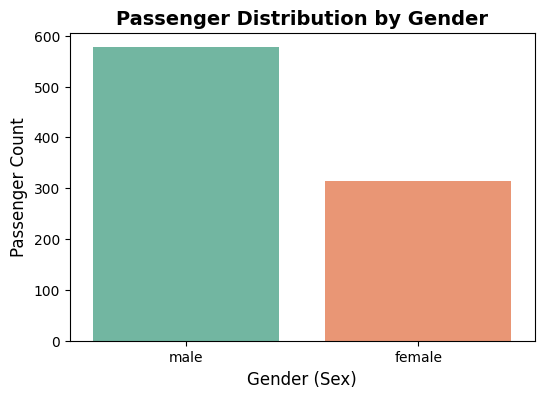

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', palette='Set2')

# Adding titles and labels
plt.title('Passenger Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender (Sex)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

# Display the chart
plt.show()

$Interpretation$

The countplot reveals a significant gender imbalance among the passengers on the Titanic.

There were substantially more male passengers (around 570+) compared to female passengers (around 310+).

Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

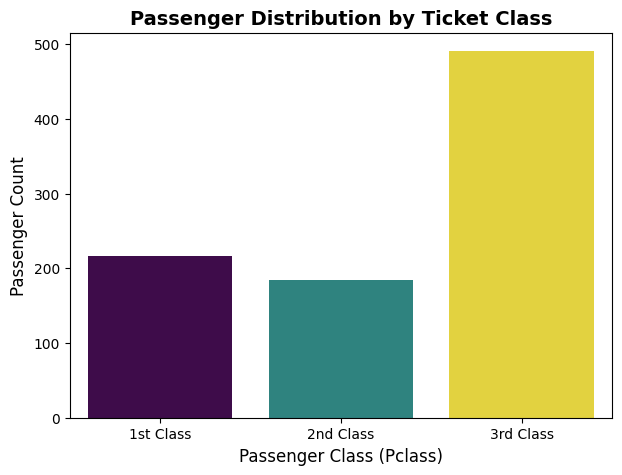

In [4]:
plt.figure(figsize=(7, 5))
# Using 'hue' mapping to ensure each class gets a distinct color
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='viridis', legend=False)

# Adding titles and labels
plt.title('Passenger Distribution by Ticket Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (Pclass)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

# Customizing x-axis labels for better readability
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])

plt.show()

$Interpretation$

The vast majority of the passengers traveled in 3rd Class, outnumbering both 1st and 2nd class combined.

1st Class had the second-highest count, while 2nd Class had the fewest passengers, indicating a highly unequal socio-economic distribution among those on board.

Q3. Create a histogram to show the distribution of passenger age.

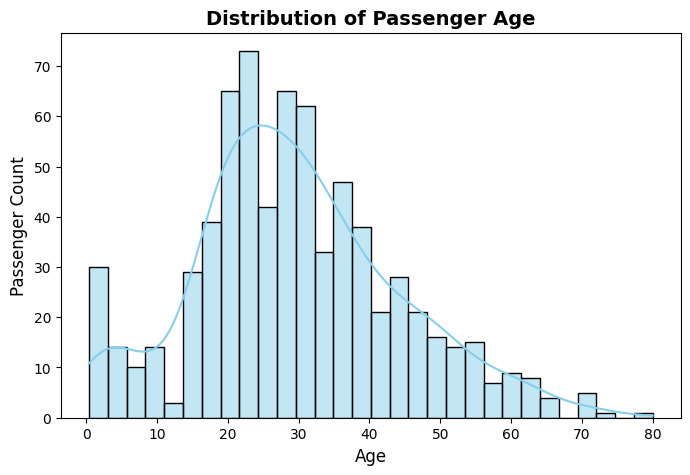

In [5]:
plt.figure(figsize=(8, 5))
# kde=True adds a kernel density estimate line to show the shape of the distribution
sns.histplot(data=df, x='Age', bins=30, kde=True, color='skyblue')

# Adding titles and labels
plt.title('Distribution of Passenger Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

plt.show()

$Interpretation$

The age distribution is right-skewed, showing that the majority of the passengers were young adults, heavily concentrated between the ages of 20 and 40.

There is also a small but noticeable spike on the far left of the chart, indicating a significant number of infants and young children on board.

Older passengers (above 60) were relatively rare.

Q4. Create a boxplot to detect outliers in the fare column.

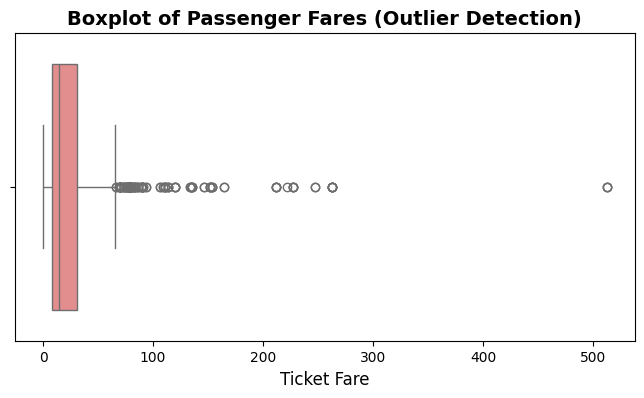

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Fare', color='lightcoral')

# Adding titles and labels
plt.title('Boxplot of Passenger Fares (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Fare', fontsize=12)

plt.show()

$Interpretation$

The boxplot highlights an extreme distribution of ticket prices. The main "box" (representing the middle 50% of the data) is squeezed heavily to the left, indicating most passengers paid low fares.

The numerous individual data points stretching far to the right represent massive outliers. A few individuals paid exceptionally high fares (with an extreme peak over 500), reflecting a drastic wealth gap among the travelers on board.

Q5. Create a scatterplot to

a. show the relationship between age and fare.

b. analyze the relationship between family size (SibSp + Parch) and fare.

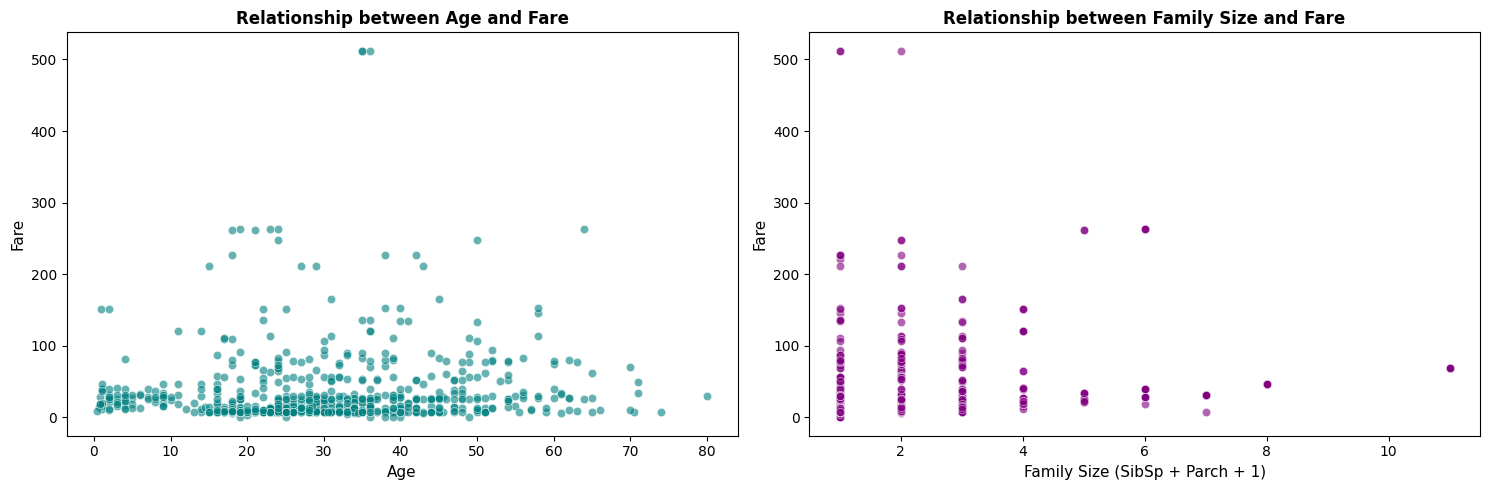

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# a. Relationship between Age and Fare
sns.scatterplot(ax=axes[0], data=df, x='Age', y='Fare', alpha=0.6, color='teal')
axes[0].set_title('Relationship between Age and Fare', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Fare', fontsize=11)

# b. Relationship between Family Size and Fare
# Calculating family size as SibSp + Parch + 1 (including the passenger themselves)
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
sns.scatterplot(ax=axes[1], data=df, x='Family_Size', y='Fare', alpha=0.6, color='purple')
axes[1].set_title('Relationship between Family Size and Fare', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Family Size (SibSp + Parch + 1)', fontsize=11)
axes[1].set_ylabel('Fare', fontsize=11)

plt.tight_layout()
plt.show()

$Interpretation$

1. Age vs. Fare: There is no strong linear correlation between age and fare. Passengers of almost all age groups are clustered at the lower end of the fare scale. However, the ultra-high fares (outliers above 500) were paid exclusively by adults, while children's fares remained relatively low and capped.

2.  Family Size vs. Fare: Single passengers (Family Size = 1) and small families (Family Sizes of 2 to 4) spans across the entire price spectrum, including the highest luxury fares. In contrast, larger families (Family Size $\ge$ 5) consistently paid lower, budget-friendly fares, showing that large groups did not travel in the highest luxury brackets.  

Q6. Create a countplot to show survival count by gender.

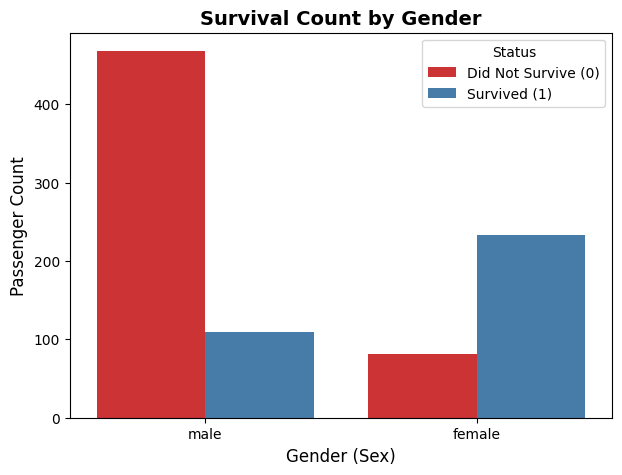

In [8]:
plt.figure(figsize=(7, 5))
# Using 'hue' to split the gender counts by survival status
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set1')

# Adding titles and labels
plt.title('Survival Count by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender (Sex)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

# Customizing the legend for clarity
plt.legend(title='Status', labels=['Did Not Survive (0)', 'Survived (1)'])

plt.show()

$Interpretation$

The chart clearly demonstrates the "women and children first" rescue protocol.

Even though there were far more men on board (as seen in Q1), the absolute number of female survivors drastically outweighs male survivors.

The vast majority of male passengers did not survive, whereas the majority of female passengers were successfully rescued.

Q7. Create a bar chart to show survival by passenger class.

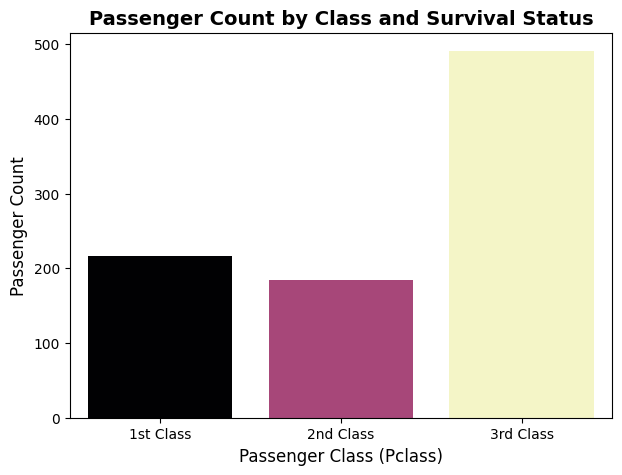

In [9]:
plt.figure(figsize=(7, 5))
# estimator=len calculates the count of passengers in each category
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', palette='magma', estimator=len, legend=False)

# Adding titles and labels
plt.title('Passenger Count by Class and Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (Pclass)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)

# Customizing x-axis labels for better readability
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])

plt.show()

$Interpretation$

While 3rd Class had by far the highest number of passengers on board (as seen in Q2), it also suffered the highest absolute number of casualties.

1st Class passengers had a significantly higher chance of survival compared to the other classes, showing a stark correlation between socioeconomic status/cabin location and safety during the evacuation.

Q8. Create a heatmap to show correlation between numerical variables.

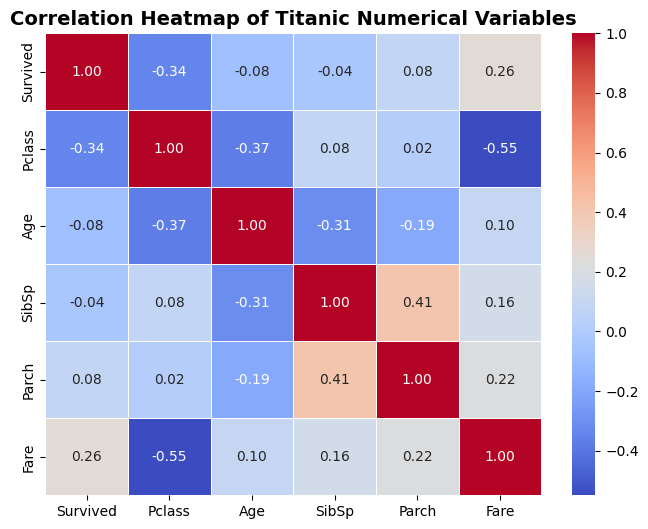

In [10]:
plt.figure(figsize=(8, 6))

# Selecting only the numerical columns for correlation analysis
numerical_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
correlation_matrix = numerical_cols.corr()

# Generating the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Adding titles
plt.title('Correlation Heatmap of Titanic Numerical Variables', fontsize=14, fontweight='bold')

plt.show()

$Interpretation$

Fare and Survival ($+0.26$): There is a moderate positive correlation between fare and survival, confirming that passengers who paid higher fares had a better chance of surviving.

Pclass and Fare ($-0.55$): A strong negative correlation exists here because 1st class is represented by a lower number (1) while 3rd class is a higher number (3). This confirms that lower class numbers paid significantly higher fares.

Pclass and Survival ($-0.34$): This negative correlation indicates that as the class number increased (moving from 1st to 3rd class), the likelihood of survival decreased.

Age and Family Variables: Age shows a slight negative correlation with sibling/spouse count (SibSp), indicating that older passengers were less likely to travel with large sibling groups or young children.

Q9. Identify which passenger class paid the highest fare on average.

In [11]:
# Grouping by passenger class and calculating the mean fare
average_fares = df.groupby('Pclass')['Fare'].mean().reset_index()

# Renaming columns for clarity
average_fares.columns = ['Passenger Class', 'Average Fare']
print(average_fares)

   Passenger Class  Average Fare
0                1     84.154687
1                2     20.662183
2                3     13.675550


$Conclusion:$ 1st Class paid the highest fare on average by a massive margin. The average ticket price for 1st class was more than 4 times higher than 2nd class, and over 6 times higher than 3rd class, highlighting the extreme wealth gap among travelers.

Q10. Write at least 5 insights from the dataset based on your visualizations

1. Strong Gender Bias in Survival ("Women and Children First"): While the passenger base was overwhelmingly male , the survival count for females was dramatically higher. This confirms that rescue efforts strictly prioritized female passengers, resulting in a significantly lower survival rate for men.

2. Socioeconomic Status Heavily Impacted Survival: Passengers in 1st Class had a much higher likelihood of survival compared to those in 2nd and 3rd Class. Despite 3rd Class having the largest population on board , they suffered the highest absolute number of casualties, pointing to a stark disparity in safety access and cabin locations.

3. Demographics Skewed Toward Young Adults: The Titanic was largely populated by young individuals, with the core demographic clustered between 20 and 40 years old. There was also a distinct subset of infants and young children on board, while elderly passengers were quite rare.

4. Extreme Wealth Disparity: The ticket fare distribution was heavily skewed. The average fare for a 1st Class ticket ($\approx \$84.15$) was more than 6 times higher than a 3rd Class ticket ($\approx \$13.68$). The presence of extreme outliers paying over $\$500$ emphasizes the massive wealth gap among the travelers.

5. Family Size Influenced Luxury Travel: Scatterplot analysis shows that ultra-high luxury fares were paid exclusively by single passengers or those traveling in small families (2 to 4 members). In contrast, larger families (5 or more members) uniformly traveled on lower-tier budget fares , suggesting that larger groups were restricted to economy accommodations.

